In [10]:
import os
import numpy as np
import matplotlib.pyplot as plt
from taxi3_wrapper import TaxiMDPWrapper  # из репозитория + корректировка

import warnings
warnings.filterwarnings("ignore")  # скинем упоминание об устаривании

# Задание 2

In [11]:
class ValueIterationSolver:
    def __init__(self, mdp, gamma=0.99, theta=1e-6):
        self.mdp = mdp
        self.gamma = gamma
        self.theta = theta
        self.V = {s: 0.0 for s in mdp.get_all_states()}
        self.policy = {s: None for s in mdp.get_all_states()}
        self.history = []  # для визуализации сходимости
        
    def solve(self, max_iterations=1000):
        for iteration in range(max_iterations):
            delta = 0
            # Policy Evaluation (одна итерация)
            for s in self.mdp.get_all_states():
                if self.mdp.is_terminal(s):
                    continue
                    
                v_old = self.V[s]
                action_values = []
                
                for a in self.mdp.get_possible_actions(s):
                    q_value = 0
                    for s_next in self.mdp.get_next_states(s, a):
                        p = self.mdp.get_transition_prob(s, a, s_next)
                        r = self.mdp.get_reward(s, a, s_next)
                        q_value += p * (r + self.gamma * self.V[s_next])
                    action_values.append((a, q_value))
                
                if action_values:
                    self.V[s] = max(q for _, q in action_values)
                    delta = max(delta, abs(v_old - self.V[s]))
            
            self.history.append(delta)
            
            if delta < self.theta:
                print(f"Сходимость достигнута на итерации {iteration}")
                break
        
        # Policy Extraction
        for s in self.mdp.get_all_states():
            if self.mdp.is_terminal(s):
                self.policy[s] = None
                continue
                
            best_action, best_value = None, -np.inf
            for a in self.mdp.get_possible_actions(s):
                q_value = 0
                for s_next in self.mdp.get_next_states(s, a):
                    p = self.mdp.get_transition_prob(s, a, s_next)
                    r = self.mdp.get_reward(s, a, s_next)
                    q_value += p * (r + self.gamma * self.V[s_next])
                
                if q_value > best_value:
                    best_value = q_value
                    best_action = a
            
            self.policy[s] = best_action
        
        return self.policy, self.V

    def get_convergence_history(self):
        return self.history


# Задание 3

In [12]:
def visualize_policy_execution(mdp, policy, max_steps=50):
    """Визуализация маршрута агента"""
    state = mdp.env.reset()
    path = [state]
    total_reward = 0
    
    print("Начальное состояние такси:")
    mdp.env.render()
    
    for step in range(max_steps):
        if mdp.is_terminal(state):
            print(f"\nПассажир доставлен. Общее вознаграждение: {total_reward}")
            break
            
        action = policy.get(state)
        if action is None:
            print("Терминальное состояние достигнуто")
            break
            
        # Выполняем действие
        next_state, reward, done, _ = mdp.env.step(action)
        total_reward += reward
        path.append(next_state)
        state = next_state
        
        if step % 5 == 0:  # Показываем промежуточные шаги
            print(f"\nШаг {step}, Действие: {action}, Вознаграждение: {reward:.1f}")
            mdp.env.render()
    
    return path, total_reward

def plot_convergence(history):
    """График сходимости алгоритма"""
    plt.figure(figsize=(10, 4))
    plt.plot(history, marker='o', markersize=3, linewidth=1.5)
    plt.yscale('log')
    plt.xlabel('Итерация')
    plt.ylabel('Макс. изменение V(s) (лог. шкала)')
    plt.title('Сходимость Value Iteration')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    os.makedirs("./graphs", exist_ok=True)
    plt.savefig('./graphs/convergence.png', dpi=150)

def plot_value_distribution(V, iteration=None):
    """Визуализация распределения value function"""
    values = [v for s, v in V.items() if not np.isinf(v) and not np.isnan(v)]
    
    plt.figure(figsize=(8, 4))
    plt.hist(values, bins=50, color='skyblue', edgecolor='black')
    plt.xlabel('V(s)')
    plt.ylabel('Частота')
    title = 'Распределение Value Function' 
    if iteration is not None:
        title += f' (итерация {iteration})'
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    os.makedirs("./graphs", exist_ok=True)
    plt.savefig(f'./graphs/value_dist_{iteration or "final"}.png', dpi=150)
    


ДЕМОНСТРАЦИЯ ОПТИМАЛЬНОЙ СТРАТЕГИИ
Начальное состояние такси:
+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+


Шаг 0, Действие: 2, Вознаграждение: -1.0
+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (East)

Шаг 5, Действие: 4, Вознаграждение: -1.0
+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (Pickup)

Шаг 10, Действие: 3, Вознаграждение: -1.0
+---------+
|R: | : :G|
| : | : : |
|_: : : : |
| | : | : |
|Y| : |B: |
+---------+
  (West)

Шаг 15, Действие: 5, Вознаграждение: 20.0
+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (Dropoff)

Шаг 20, Действие: 4, Вознаграждение: -1.0
+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (Pickup)

Шаг 25, Действие: 5, Вознаграждение: 20.0
+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (Dropoff)

Шаг 30, Действие: 4, Вознаг

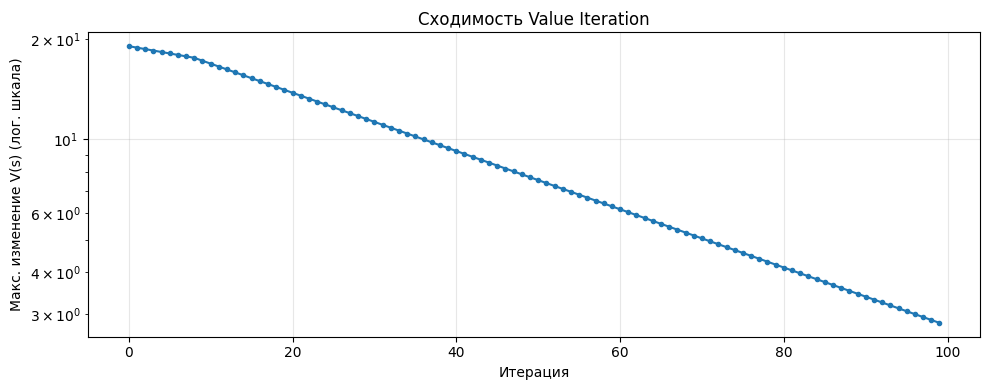

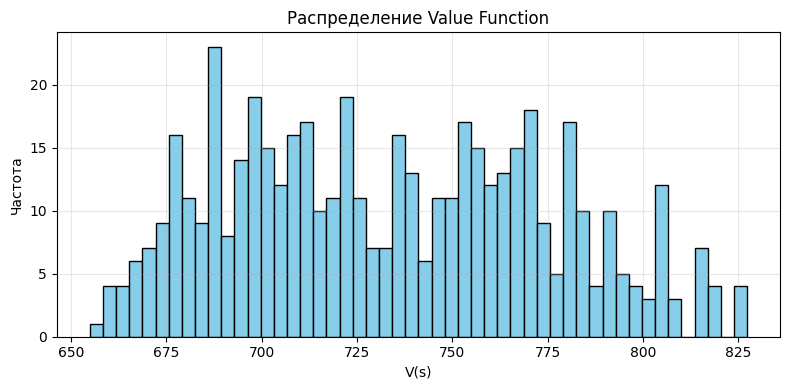

In [13]:
if __name__ == "__main__":
    # 1. Инициализация среды
    mdp = TaxiMDPWrapper('Taxi-v3')
    
    # 2. Обучение стратегии
    solver = ValueIterationSolver(mdp, gamma=0.99)
    policy, V = solver.solve(max_iterations=100)
    
    # 3. Визуализация сходимости
    plot_convergence(solver.get_convergence_history())
    plot_value_distribution(V)
    
    # 4. Демонстрация работы стратегии
    print("\n" + "="*50)
    print("ДЕМОНСТРАЦИЯ ОПТИМАЛЬНОЙ СТРАТЕГИИ")
    print("="*50)
    path, total_reward = visualize_policy_execution(mdp, policy)
    
    # 5. Статистика
    print("\n" + "="*50)
    print(f"Статистика выполнения:")
    print(f"- Пройдено шагов: {len(path)-1}")
    print(f"- Общее вознаграждение: {total_reward:.1f}")
    print(f"- Среднее вознаграждение за шаг: {total_reward/(len(path)-1):.2f}")
    print("="*50)